# Phát Hiện Bất Thường Theo Luật Nghiệp Vụ dựa trên Session người dùng trong web thương mại điện tử

## RetailRocket E-Commerce Dataset

Dataset: https://www.kaggle.com/datasets/retailrocket/ecommerce-dataset

Đơn vị phân tích chính là `session_id`, được tạo từ `visitorid` và khoảng nghỉ 30 phút giữa hai sự kiện liên tiếp. Dataset không có nhãn bất thường thật, vì vậy nhãn `is_anomaly_rule` và `anomaly_types` là pseudo-label do nhóm thiết kế bằng luật nghiệp vụ.

## Hệ thống business rules và anomaly types

| Mã | Anomaly type | Mô tả nghiệp vụ | Dấu hiệu chính trong notebook |
| --- | --- | --- | --- |
| BR01 | Bot scraper | Session có hành vi duyệt tự động hoặc quét dữ liệu nhanh. | Nhiều event trong session hoặc tốc độ event/phút cao. |
| BR02 | Ghost buyer | Có giao dịch nhưng không có bước thêm giỏ trong cùng session. | `transaction > 0` và `addtocart = 0`. |
| BR03 | Click fraud | Xem nhiều sản phẩm nhưng không có ý định mua hoặc thêm giỏ. | Nhiều `view`, không có `addtocart`, không có `transaction`. |
| BR04 | Rapid-fire | Các thao tác diễn ra quá sát nhau, giống bot/script. | Có event liên tiếp dưới 1 giây hoặc tỉ lệ rapid-fire cao. |
| BR05 | Night crawler | Session hoạt động chủ yếu vào khung giờ đêm. | Tỉ lệ event 0h-5h cao và session đủ số event tối thiểu. |
| BR06 | Item hoarding | Thêm cùng một sản phẩm vào giỏ nhiều lần trong một session. | `max_same_item_atc` vượt ngưỡng. |
| BR07 | Session bomb | Session xem/quét quá nhiều item khác nhau. | `unique_items` cao. |
| BR08 | Sequence violation | Thứ tự hành vi bất thường: mua trước khi xem/thêm giỏ cùng item. | `transaction` xuất hiện trước `view/addtocart` của cùng item trong session. |
| BR09 | Transaction burst | Session có số lượng giao dịch cao bất thường. | `n_transaction` vượt ngưỡng. |
| BR10 | Cart abandonment | Thêm nhiều sản phẩm vào giỏ nhưng không giao dịch. | `n_addtocart` cao và `n_transaction = 0`. |
| BR11 | Repeated view spam | Xem lặp lại cùng một item quá nhiều lần. | `max_same_item_view` vượt ngưỡng. |
| BR12 | Category scanning | Quét nhiều nhóm danh mục sản phẩm trong một session. | `unique_categories` cao nếu dữ liệu category khả dụng. |

Các rule này dùng để gắn nhãn multi-label cho session. Một session có thể vừa là `Bot scraper`, vừa là `Rapid-fire`, vừa là `Session bomb`. Các thuật toán ML dùng pseudo-label này để so sánh/mô phỏng, không được diễn giải như nhãn gian lận thật.

Phần mô hình được chia thành `train`, `validation`, `test`. Validation dùng để chọn threshold dự đoán; test dùng để báo cáo kết quả cuối.


## Phân công thuật toán

| Thành viên | Thuật toán | Loại | Vai trò trong đồ án |
| --- | --- | --- | --- |
| Đình Tuấn | XGBoost | Phân loại có giám sát | Mô hình boosting mạnh, xử lý dữ liệu phi tuyến và mất cân bằng lớp |
| Lê Văn Anh | Decision Tree | Phân loại có giám sát | Mô hình dễ giải thích, minh họa được luật quyết định |
| Tuấn Anh | Random Forest | Phân loại có giám sát | Ensemble nhiều cây, ổn định hơn cây đơn và có feature importance |
| Thủy | LightGBM | Phân loại có giám sát | Gradient boosting leaf-wise, nhanh và hiệu quả trên dữ liệu dạng bảng; so sánh thêm với XGBoost |
| Đức Anh | Isolation Forest | Phát hiện bất thường không giám sát | Thuật toán chuyên biệt cho anomaly detection |

## 1. Import và cấu hình

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    hamming_loss,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

try:
    from xgboost import XGBClassifier
except Exception as import_error:
    raise ImportError(
        "Chưa nạp được XGBoost. Cài package bằng `.venv/bin/python -m pip install xgboost`; "
        "trên macOS cần thêm OpenMP runtime bằng `brew install libomp`."
    ) from import_error

try:
    from lightgbm import LGBMClassifier
except Exception as import_error:
    raise ImportError(
        "Chưa nạp được LightGBM. Cài package bằng `.venv/bin/python -m pip install lightgbm`; "
        "trên macOS nếu gặp lỗi OpenMP thì cài `brew install libomp`."
    ) from import_error

warnings.filterwarnings('ignore')

RANDOM_STATE = 10
OUTPUT_DIR = Path('.')
DATA_PATH = Path('./data/events.csv')
SESSION_GAP_SEC = 30 * 60

MAX_SUPERVISED_ROWS = 3_000_000
IFOREST_TRAIN_ROWS = 250_000
PLOT_SAMPLE_ROWS = 30_000

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
COLORS = {
    'normal': '#2E7D32',
    'anomaly': '#C62828',
    'warning': '#EF6C00',
    'primary': '#1565C0',
    'secondary': '#6A1B9A',
    'dark': '#263238',
    'muted': '#607D8B',
}

print('Thư viện và cấu hình đã sẵn sàng')

Thư viện và cấu hình đã sẵn sàng


## 2. Tải dữ liệu, tiền xử lý và tạo session

Session được định nghĩa bằng khoảng nghỉ 30 phút giữa hai event liên tiếp của cùng `visitorid`.

In [2]:
print('Đang tải dữ liệu events.csv...')
events = pd.read_csv(DATA_PATH)

required_columns = {'timestamp', 'visitorid', 'event', 'itemid', 'transactionid'}
missing_columns = required_columns.difference(events.columns)
if missing_columns:
    raise ValueError(f'Thiếu cột bắt buộc: {sorted(missing_columns)}')

rows_before_dedup = len(events)
events = events.drop_duplicates().reset_index(drop=True)
duplicate_count = rows_before_dedup - len(events)

events = events[events['event'].isin(['view', 'addtocart', 'transaction'])].copy()

events['datetime'] = pd.to_datetime(events['timestamp'], unit='ms')
events['date'] = events['datetime'].dt.date
events['hour'] = events['datetime'].dt.hour
events['dayofweek'] = events['datetime'].dt.dayofweek

events = events.sort_values(['visitorid', 'timestamp', 'event', 'itemid']).reset_index(drop=True)
events['prev_timestamp'] = events.groupby('visitorid')['timestamp'].shift(1)
events['time_diff_sec'] = (events['timestamp'] - events['prev_timestamp']) / 1000

is_new_session = events['time_diff_sec'].isna() | (events['time_diff_sec'] > SESSION_GAP_SEC)
events['session_number'] = is_new_session.groupby(events['visitorid']).cumsum().astype('int32')
events['session_id'] = events['visitorid'].astype(str) + '_S' + events['session_number'].astype(str)

events['prev_session_timestamp'] = events.groupby('session_id')['timestamp'].shift(1)
events['time_diff_session_sec'] = (events['timestamp'] - events['prev_session_timestamp']) / 1000

session_count = events['session_id'].nunique()
print(f'Số dòng trùng lặp đã xóa: {duplicate_count:,}')
print(f'Tổng số sự kiện sau tiền xử lý: {len(events):,}')
print(f'Số visitor duy nhất: {events["visitorid"].nunique():,}')
print(f'Số session tạo ra: {session_count:,}')
print(f'Trung bình sự kiện/session: {len(events) / session_count:.2f}')
print(f'Khoảng thời gian: {events["datetime"].min()} -> {events["datetime"].max()}')
print('\nPhân phối loại sự kiện:')
display(events['event'].value_counts().rename_axis('event').reset_index(name='count'))

Đang tải dữ liệu events.csv...
Số dòng trùng lặp đã xóa: 460
Tổng số sự kiện sau tiền xử lý: 2,755,641
Số visitor duy nhất: 1,407,580
Số session tạo ra: 1,761,675
Trung bình sự kiện/session: 1.56
Khoảng thời gian: 2015-05-03 03:00:04.384000 -> 2015-09-18 02:59:47.788000

Phân phối loại sự kiện:


,event,count
0,view,2664218
1,addtocart,68966
2,transaction,22457


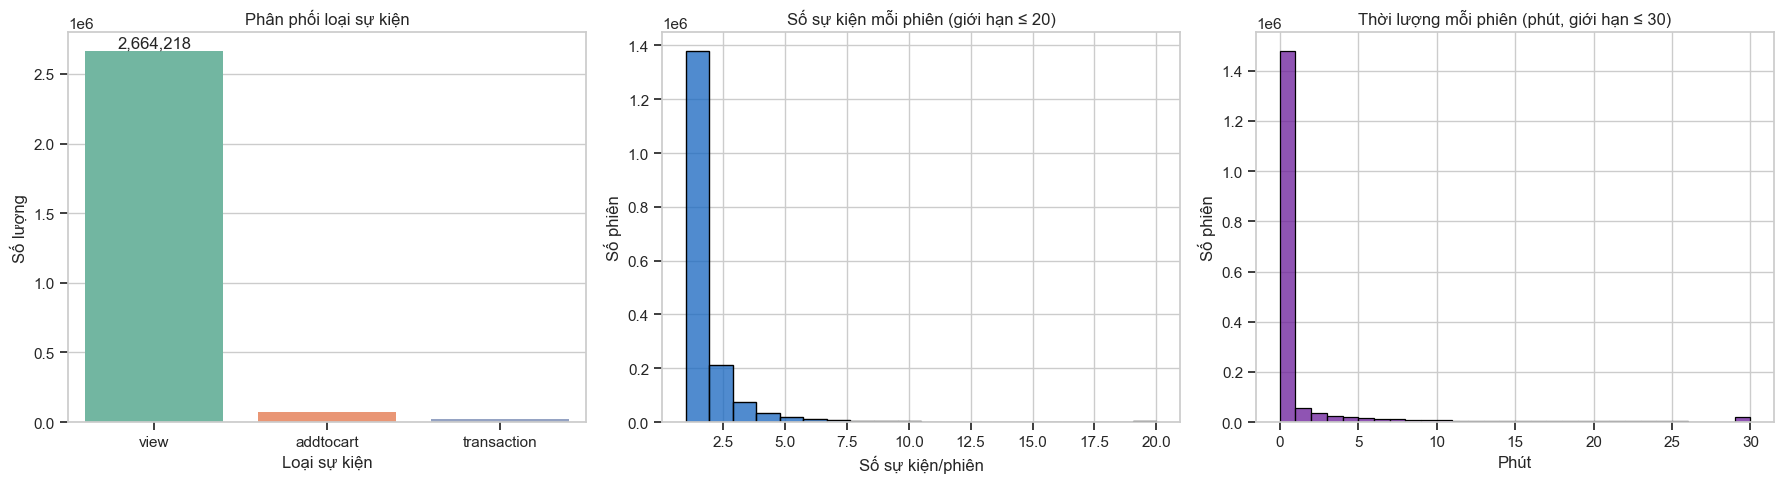

In [3]:
session_sizes = events.groupby('session_id').size()
session_duration = (events.groupby('session_id')['timestamp'].max() - events.groupby('session_id')['timestamp'].min()) / 1000

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

order = events['event'].value_counts().index
sns.countplot(data=events, x='event', order=order, ax=axes[0], palette='Set2')
axes[0].set_title('Phân phối loại sự kiện')
axes[0].set_xlabel('Loại sự kiện')
axes[0].set_ylabel('Số lượng')
axes[0].bar_label(axes[0].containers[0], fmt='{:,.0f}')

sns.histplot(session_sizes.clip(upper=20), bins=20, color=COLORS['primary'], ax=axes[1])
axes[1].set_title('Số sự kiện mỗi phiên (giới hạn ≤ 20)')
axes[1].set_xlabel('Số sự kiện/phiên')
axes[1].set_ylabel('Số phiên')

sns.histplot((session_duration / 60).clip(upper=30), bins=30, color=COLORS['secondary'], ax=axes[2])
axes[2].set_title('Thời lượng mỗi phiên (phút, giới hạn ≤ 30)')
axes[2].set_xlabel('Phút')
axes[2].set_ylabel('Số phiên')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_session_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

## 3. Xây dựng session behavior profile

Mỗi dòng của bảng profile tương ứng với một `session_id`. `visitorid` chỉ còn là metadata để truy vết người dùng.

In [4]:
print('Đang xây dựng session behavior profile...')
session_events = events.copy()
session_groups = session_events.groupby('session_id', sort=False)

session_profile = pd.DataFrame(index=session_groups.size().index)
session_profile.index.name = 'session_id'
session_profile['visitorid'] = session_groups['visitorid'].first().astype('int64')
session_profile['session_number'] = session_groups['session_number'].first().astype('int32')
session_profile['session_start'] = session_groups['datetime'].min()
session_profile['session_end'] = session_groups['datetime'].max()
session_profile['session_start_hour'] = session_profile['session_start'].dt.hour
session_profile['session_dayofweek'] = session_profile['session_start'].dt.dayofweek
session_profile['total_events'] = session_groups.size().astype('int32')
session_profile['unique_items'] = session_groups['itemid'].nunique().astype('int32')
session_profile['active_hours'] = session_groups['hour'].nunique().astype('int16')
session_profile['session_duration_sec'] = ((session_groups['timestamp'].max() - session_groups['timestamp'].min()) / 1000).astype('float32')

event_counts = session_events.groupby(['session_id', 'event']).size().unstack(fill_value=0)
event_counts.columns = [f'n_{column}' for column in event_counts.columns]
for column in ['n_view', 'n_addtocart', 'n_transaction']:
    if column not in event_counts.columns:
        event_counts[column] = 0
session_profile = session_profile.join(event_counts[['n_view', 'n_addtocart', 'n_transaction']].astype('int32'))
session_profile['unique_event_types'] = (session_profile[['n_view', 'n_addtocart', 'n_transaction']] > 0).sum(axis=1).astype('int8')

event_probabilities = event_counts[['n_view', 'n_addtocart', 'n_transaction']].div(session_profile['total_events'].clip(lower=1), axis=0)
session_profile['event_type_entropy'] = (-(event_probabilities.replace(0, np.nan) * np.log2(event_probabilities.replace(0, np.nan))).sum(axis=1)).fillna(0).astype('float32')

hour_counts = session_events.groupby(['session_id', 'hour']).size().unstack(fill_value=0)
hour_probabilities = hour_counts.div(hour_counts.sum(axis=1).clip(lower=1), axis=0)
session_profile['hour_entropy'] = (-(hour_probabilities.replace(0, np.nan) * np.log2(hour_probabilities.replace(0, np.nan))).sum(axis=1)).fillna(0).astype('float32')

events_with_interval = session_events.dropna(subset=['time_diff_session_sec'])
interval_stats = events_with_interval.groupby('session_id')['time_diff_session_sec'].agg(
    min_interval_sec='min',
    mean_interval_sec='mean',
    median_interval_sec='median',
    std_interval_sec='std',
    max_interval_sec='max',
)
session_profile = session_profile.join(interval_stats).fillna({
    'min_interval_sec': 0,
    'mean_interval_sec': 0,
    'median_interval_sec': 0,
    'std_interval_sec': 0,
    'max_interval_sec': 0,
})
interval_columns = ['min_interval_sec', 'mean_interval_sec', 'median_interval_sec', 'std_interval_sec', 'max_interval_sec']
session_profile[interval_columns] = session_profile[interval_columns].astype('float32')

session_profile['rapid_fire_count'] = events_with_interval[events_with_interval['time_diff_session_sec'] < 1].groupby('session_id').size().reindex(session_profile.index, fill_value=0).astype('int16')
session_profile['night_events'] = session_events[session_events['hour'].between(0, 5)].groupby('session_id').size().reindex(session_profile.index, fill_value=0).astype('int16')
session_profile['peak_events'] = session_events[session_events['hour'].between(9, 21)].groupby('session_id').size().reindex(session_profile.index, fill_value=0).astype('int16')
session_profile['weekend_events'] = session_events[session_events['dayofweek'].isin([5, 6])].groupby('session_id').size().reindex(session_profile.index, fill_value=0).astype('int16')

view_events = session_events[session_events['event'] == 'view']
if len(view_events) > 0:
    max_same_item_view = view_events.groupby(['session_id', 'itemid']).size().groupby('session_id').max()
    session_profile['max_same_item_view'] = max_same_item_view.reindex(session_profile.index, fill_value=0).astype('int16')
else:
    session_profile['max_same_item_view'] = 0

addtocart_events = session_events[session_events['event'] == 'addtocart']
if len(addtocart_events) > 0:
    max_same_item_addtocart = addtocart_events.groupby(['session_id', 'itemid']).size().groupby('session_id').max()
    session_profile['max_same_item_atc'] = max_same_item_addtocart.reindex(session_profile.index, fill_value=0).astype('int16')
else:
    session_profile['max_same_item_atc'] = 0

session_profile['duration_min'] = (session_profile['session_duration_sec'] / 60).clip(lower=1).astype('float32')
session_profile['events_per_minute'] = (session_profile['total_events'] / session_profile['duration_min']).astype('float32')
session_profile['view_rate'] = (session_profile['n_view'] / session_profile['total_events'].clip(lower=1)).astype('float32')
session_profile['atc_rate'] = (session_profile['n_addtocart'] / session_profile['n_view'].clip(lower=1)).astype('float32')
session_profile['buy_rate'] = (session_profile['n_transaction'] / session_profile['n_view'].clip(lower=1)).astype('float32')
session_profile['night_ratio'] = (session_profile['night_events'] / session_profile['total_events'].clip(lower=1)).astype('float32')
session_profile['peak_ratio'] = (session_profile['peak_events'] / session_profile['total_events'].clip(lower=1)).astype('float32')
session_profile['weekend_ratio'] = (session_profile['weekend_events'] / session_profile['total_events'].clip(lower=1)).astype('float32')
session_profile['rapid_ratio'] = (session_profile['rapid_fire_count'] / session_profile['total_events'].clip(lower=1)).astype('float32')
session_profile['items_per_event'] = (session_profile['unique_items'] / session_profile['total_events'].clip(lower=1)).astype('float32')
session_profile['view_to_cart_ratio'] = (session_profile['n_view'] / session_profile['n_addtocart'].clip(lower=1)).astype('float32')
session_profile['cart_to_transaction_ratio'] = (session_profile['n_addtocart'] / session_profile['n_transaction'].clip(lower=1)).astype('float32')

session_profile['unique_categories'] = 0
session_profile['unique_parent_categories'] = 0
try:
    item_properties_part1 = pd.read_csv('./data/item_properties_part1.csv', usecols=['itemid', 'property', 'value'])
    item_properties_part2 = pd.read_csv('./data/item_properties_part2.csv', usecols=['itemid', 'property', 'value'])
    item_categories = pd.concat([item_properties_part1, item_properties_part2], ignore_index=True)
    item_categories = item_categories[item_categories['property'].astype(str) == 'categoryid'][['itemid', 'value']]
    item_categories['categoryid'] = pd.to_numeric(item_categories['value'], errors='coerce')
    item_categories = item_categories.dropna(subset=['categoryid']).drop_duplicates('itemid')
    item_categories['categoryid'] = item_categories['categoryid'].astype('int64')

    category_tree = pd.read_csv('./data/category_tree.csv')
    category_parent = category_tree[['categoryid', 'parentid']].drop_duplicates('categoryid')
    item_categories = item_categories.merge(category_parent, on='categoryid', how='left')

    session_items = session_events[['session_id', 'itemid']].drop_duplicates()
    session_items = session_items.merge(item_categories[['itemid', 'categoryid', 'parentid']], on='itemid', how='left')
    session_profile['unique_categories'] = session_items.groupby('session_id')['categoryid'].nunique().reindex(session_profile.index, fill_value=0).astype('int16')
    session_profile['unique_parent_categories'] = session_items.groupby('session_id')['parentid'].nunique().reindex(session_profile.index, fill_value=0).astype('int16')
    print('Đã bổ sung đặc trưng danh mục từ item_properties và category_tree')
except Exception as category_error:
    print(f'Bỏ qua đặc trưng danh mục vì không nạp được item properties: {category_error}')

print(f'Kích thước session profile: {session_profile.shape}')
print(f'session_id là duy nhất: {session_profile.index.is_unique}')
display(session_profile.head())

Đang xây dựng session behavior profile...
Đã bổ sung đặc trưng danh mục từ item_properties và category_tree
Kích thước session profile: (1761675, 41)
session_id là duy nhất: True


,visitorid,session_number,session_start,session_end,session_start_hour,session_dayofweek,total_events,unique_items,active_hours,session_duration_sec,...,buy_rate,night_ratio,peak_ratio,weekend_ratio,rapid_ratio,items_per_event,view_to_cart_ratio,cart_to_transaction_ratio,unique_categories,unique_parent_categories
session_id,,,,,,,,,,,,,,,,,,,,,
0_S1,0,1,2015-09-11 20:49:49.439,2015-09-11 20:55:17.175,20,4,3,3,1,327.735992,...,0.0,0.0,1.0,0.0,0.0,1.0,3.0,0.0,3,2
1_S1,1,1,2015-08-13 17:46:06.444,2015-08-13 17:46:06.444,17,3,1,1,1,0.000000,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1,1
2_S1,2,1,2015-08-07 17:51:44.567,2015-08-07 18:20:57.845,17,4,8,4,2,1753.277954,...,0.0,0.0,1.0,0.0,0.0,0.5,8.0,0.0,2,1
3_S1,3,1,2015-08-01 07:10:35.296,2015-08-01 07:10:35.296,7,5,1,1,1,0.000000,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1,1
4_S1,4,1,2015-09-15 21:24:27.167,2015-09-15 21:24:27.167,21,1,1,1,1,0.000000,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0,0


In [5]:
summary_cols = [
    'total_events', 'unique_items', 'unique_categories', 'unique_parent_categories',
    'session_duration_sec', 'events_per_minute', 'n_view', 'n_addtocart', 'n_transaction',
    'rapid_fire_count', 'rapid_ratio', 'night_ratio', 'max_same_item_view', 'max_same_item_atc',
    'event_type_entropy', 'hour_entropy',
]
profile_summary = session_profile[summary_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T
print('Thống kê các đặc trưng session chính:')
display(profile_summary)

Thống kê các đặc trưng session chính:


,count,mean,std,min,50%,75%,90%,95%,99%,max
total_events,1761675.0,1.564216,2.599172,1.000000,1.0,1.0,2.000000,4.00000,9.000000,417.000000
unique_items,1761675.0,1.332739,1.784379,1.000000,1.0,1.0,2.000000,3.00000,6.000000,389.000000
unique_categories,1761675.0,0.964344,0.892530,0.000000,1.0,1.0,1.000000,1.00000,3.000000,114.000000
unique_parent_categories,1761675.0,0.942344,0.755826,0.000000,1.0,1.0,1.000000,1.00000,2.000000,79.000000
session_duration_sec,1761675.0,105.243446,499.529755,0.000000,0.0,0.0,213.162402,624.14751,1792.538149,43704.246094
events_per_minute,1761675.0,1.039757,0.440438,0.048184,1.0,1.0,1.116754,2.00000,3.000000,29.099926
n_view,1761675.0,1.512321,2.352375,0.000000,1.0,1.0,2.000000,4.00000,8.000000,417.000000
n_addtocart,1761675.0,0.039148,0.397012,0.000000,0.0,0.0,0.000000,0.00000,1.000000,114.000000
n_transaction,1761675.0,0.012748,0.207124,0.000000,0.0,0.0,0.000000,0.00000,0.000000,59.000000
rapid_fire_count,1761675.0,0.009295,0.181702,0.000000,0.0,0.0,0.000000,0.00000,0.000000,66.000000


## 4. Business rules và multi-label anomaly tagging theo session

Các luật gắn nhãn hành vi đáng nghi ở cấp session. Một session có thể mang nhiều anomaly type cùng lúc.

In [6]:
THRESHOLDS = {
    'BR01_min_events_bot': 12,
    'BR01_min_events_per_minute': 8,
    'BR01_min_events_for_speed': 5,
    'BR03_min_views_for_click_fraud': 6,
    'BR04_rapid_fire_count': 1,
    'BR04_rapid_fire_ratio': 0.20,
    'BR04_min_events_for_rapid': 3,
    'BR05_night_ratio': 0.75,
    'BR05_min_events_for_night': 4,
    'BR06_max_same_item_atc': 1,
    'BR07_min_unique_items_session_bomb': 12,
    'BR09_min_transactions_burst': 3,
    'BR10_min_addtocart_abandonment': 10,
    'BR11_max_same_item_view': 20,
    'BR12_min_unique_categories': 20,
}

sessions = session_profile.copy()

sessions['flag_BR01_bot_scraper'] = (
    (sessions['total_events'] >= THRESHOLDS['BR01_min_events_bot'])
    | (
        (sessions['events_per_minute'] >= THRESHOLDS['BR01_min_events_per_minute'])
        & (sessions['total_events'] >= THRESHOLDS['BR01_min_events_for_speed'])
    )
).astype(int)

sessions['flag_BR02_ghost_buyer'] = (
    (sessions['n_transaction'] > 0) & (sessions['n_addtocart'] == 0)
).astype(int)

sessions['flag_BR03_click_fraud'] = (
    (sessions['n_view'] >= THRESHOLDS['BR03_min_views_for_click_fraud'])
    & (sessions['n_addtocart'] == 0)
    & (sessions['n_transaction'] == 0)
).astype(int)

sessions['flag_BR04_rapid_fire'] = (
    (
        (sessions['rapid_fire_count'] >= THRESHOLDS['BR04_rapid_fire_count'])
        | (sessions['rapid_ratio'] >= THRESHOLDS['BR04_rapid_fire_ratio'])
    )
    & (sessions['total_events'] >= THRESHOLDS['BR04_min_events_for_rapid'])
).astype(int)

sessions['flag_BR05_night_crawler'] = (
    (sessions['night_ratio'] >= THRESHOLDS['BR05_night_ratio'])
    & (sessions['total_events'] >= THRESHOLDS['BR05_min_events_for_night'])
).astype(int)

sessions['flag_BR06_item_hoarding'] = (
    sessions['max_same_item_atc'] > THRESHOLDS['BR06_max_same_item_atc']
).astype(int)

sessions['flag_BR07_session_bomb'] = (
    sessions['unique_items'] >= THRESHOLDS['BR07_min_unique_items_session_bomb']
).astype(int)

interaction_event = session_events['event'].isin(['view', 'addtocart']).astype('int8')
prior_item_interactions = interaction_event.groupby([session_events['session_id'], session_events['itemid']]).cumsum()
sequence_violation_sessions = session_events.loc[
    (session_events['event'] == 'transaction') & (prior_item_interactions == 0),
    'session_id',
].unique()
sessions['flag_BR08_sequence_violation'] = sessions.index.isin(sequence_violation_sessions).astype(int)

sessions['flag_BR09_transaction_burst'] = (
    sessions['n_transaction'] >= THRESHOLDS['BR09_min_transactions_burst']
).astype(int)

sessions['flag_BR10_cart_abandonment'] = (
    (sessions['n_addtocart'] >= THRESHOLDS['BR10_min_addtocart_abandonment'])
    & (sessions['n_transaction'] == 0)
).astype(int)

sessions['flag_BR11_repeated_view_spam'] = (
    sessions['max_same_item_view'] >= THRESHOLDS['BR11_max_same_item_view']
).astype(int)

sessions['flag_BR12_category_scanning'] = (
    sessions['unique_categories'] >= THRESHOLDS['BR12_min_unique_categories']
).astype(int)

anomaly_type_map = {
    'flag_BR01_bot_scraper': 'Bot scraper',
    'flag_BR02_ghost_buyer': 'Ghost buyer',
    'flag_BR03_click_fraud': 'Click fraud',
    'flag_BR04_rapid_fire': 'Rapid-fire',
    'flag_BR05_night_crawler': 'Night crawler',
    'flag_BR06_item_hoarding': 'Item hoarding',
    'flag_BR07_session_bomb': 'Session bomb',
    'flag_BR08_sequence_violation': 'Sequence violation',
    'flag_BR09_transaction_burst': 'Transaction burst',
    'flag_BR10_cart_abandonment': 'Cart abandonment',
    'flag_BR11_repeated_view_spam': 'Repeated view spam',
    'flag_BR12_category_scanning': 'Category scanning',
}

flag_cols = list(anomaly_type_map.keys())
sessions['total_flags'] = sessions[flag_cols].sum(axis=1)
sessions['is_anomaly_rule'] = (sessions['total_flags'] > 0).astype(int)
sessions['is_anomaly'] = sessions['is_anomaly_rule']

flag_matrix = sessions[flag_cols].to_numpy(dtype=bool)
anomaly_type_labels = np.array(list(anomaly_type_map.values()), dtype=object)
sessions['anomaly_type_count'] = flag_matrix.sum(axis=1).astype(int)
sessions['anomaly_types'] = [
    ', '.join(anomaly_type_labels[row_flags].tolist()) if row_flags.any() else 'Normal'
    for row_flags in flag_matrix
]

if not (sessions['anomaly_type_count'] == sessions['total_flags']).all():
    raise ValueError('anomaly_type_count phải bằng total_flags')
if not (sessions.loc[sessions['is_anomaly'] == 0, 'anomaly_types'] == 'Normal').all():
    raise ValueError('Session bình thường phải có anomaly_types = Normal')

rule_summary = (
    sessions[flag_cols]
    .sum()
    .rename('count')
    .reset_index()
    .rename(columns={'index': 'flag'})
)
rule_summary['anomaly_type'] = rule_summary['flag'].map(anomaly_type_map)
rule_summary['percent_sessions'] = rule_summary['count'] / len(sessions) * 100
rule_summary = rule_summary[['flag', 'anomaly_type', 'count', 'percent_sessions']].sort_values('count', ascending=False)
anomaly_type_breakdown = rule_summary[['anomaly_type', 'count', 'percent_sessions']].copy()

session_anomaly_tags = sessions[
    ['visitorid', 'session_number', 'is_anomaly', 'anomaly_types', 'anomaly_type_count', 'total_flags'] + flag_cols
].reset_index()

print('Ngưỡng luật nghiệp vụ ở cấp session:')
for threshold_name, threshold_value in THRESHOLDS.items():
    print(f'- {threshold_name}: {threshold_value}')

print(f'\nSố session bất thường theo luật: {sessions["is_anomaly_rule"].sum():,} / {len(sessions):,} '
      f'({sessions["is_anomaly_rule"].mean() * 100:.2f}%)')
display(rule_summary)
print('\nVí dụ multi-label anomaly tagging theo session:')
display(session_anomaly_tags[session_anomaly_tags['is_anomaly'] == 1].head(10))

Ngưỡng luật nghiệp vụ ở cấp session:
- BR01_min_events_bot: 12
- BR01_min_events_per_minute: 8
- BR01_min_events_for_speed: 5
- BR03_min_views_for_click_fraud: 6
- BR04_rapid_fire_count: 1
- BR04_rapid_fire_ratio: 0.2
- BR04_min_events_for_rapid: 3
- BR05_night_ratio: 0.75
- BR05_min_events_for_night: 4
- BR06_max_same_item_atc: 1
- BR07_min_unique_items_session_bomb: 12
- BR09_min_transactions_burst: 3
- BR10_min_addtocart_abandonment: 10
- BR11_max_same_item_view: 20
- BR12_min_unique_categories: 20

Số session bất thường theo luật: 61,849 / 1,761,675 (3.51%)


,flag,anomaly_type,count,percent_sessions
2,flag_BR03_click_fraud,Click fraud,31213,1.771780
4,flag_BR05_night_crawler,Night crawler,30130,1.710304
0,flag_BR01_bot_scraper,Bot scraper,10884,0.617821
3,flag_BR04_rapid_fire,Rapid-fire,8052,0.457065
6,flag_BR07_session_bomb,Session bomb,5112,0.290178
5,flag_BR06_item_hoarding,Item hoarding,3212,0.182326
1,flag_BR02_ghost_buyer,Ghost buyer,2365,0.134247
7,flag_BR08_sequence_violation,Sequence violation,1573,0.089290
8,flag_BR09_transaction_burst,Transaction burst,1558,0.088439
11,flag_BR12_category_scanning,Category scanning,628,0.035648



Ví dụ multi-label anomaly tagging theo session:


,session_id,visitorid,session_number,is_anomaly,anomaly_types,anomaly_type_count,total_flags,flag_BR01_bot_scraper,flag_BR02_ghost_buyer,flag_BR03_click_fraud,flag_BR04_rapid_fire,flag_BR05_night_crawler,flag_BR06_item_hoarding,flag_BR07_session_bomb,flag_BR08_sequence_violation,flag_BR09_transaction_burst,flag_BR10_cart_abandonment,flag_BR11_repeated_view_spam,flag_BR12_category_scanning
2,2_S1,2,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
63,51_S1,51,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
66,54_S1,54,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
140,97_S1,97,1,1,"Click fraud, Night crawler",2,2,0,0,1,0,1,0,0,0,0,0,0,0
218,162_S1,162,1,1,Night crawler,1,1,0,0,0,0,1,0,0,0,0,0,0,0
234,172_S2,172,2,1,"Bot scraper, Click fraud, Night crawler, Sessi...",4,4,1,0,1,0,1,0,1,0,0,0,0,0
235,172_S3,172,3,1,"Click fraud, Night crawler",2,2,0,0,1,0,1,0,0,0,0,0,0,0
236,172_S4,172,4,1,"Bot scraper, Rapid-fire, Night crawler, Item h...",4,4,1,0,0,1,1,1,0,0,0,0,0,0
293,224_S1,224,1,1,"Bot scraper, Click fraud, Night crawler",3,3,1,0,1,0,1,0,0,0,0,0,0,0
336,264_S1,264,1,1,Rapid-fire,1,1,0,0,0,1,0,0,0,0,0,0,0,0


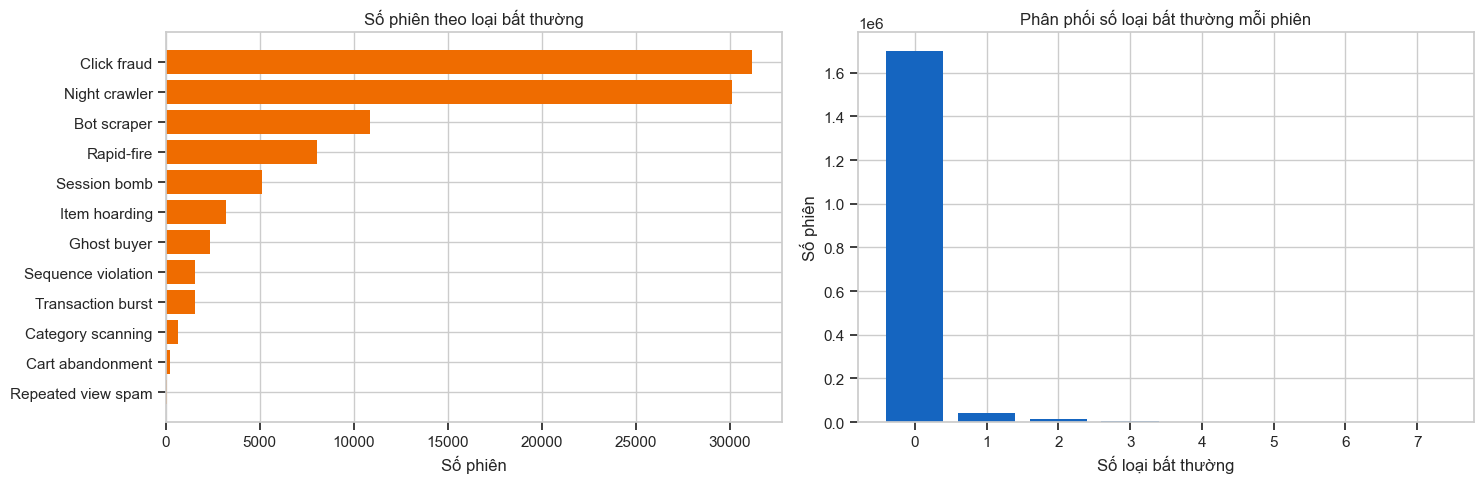

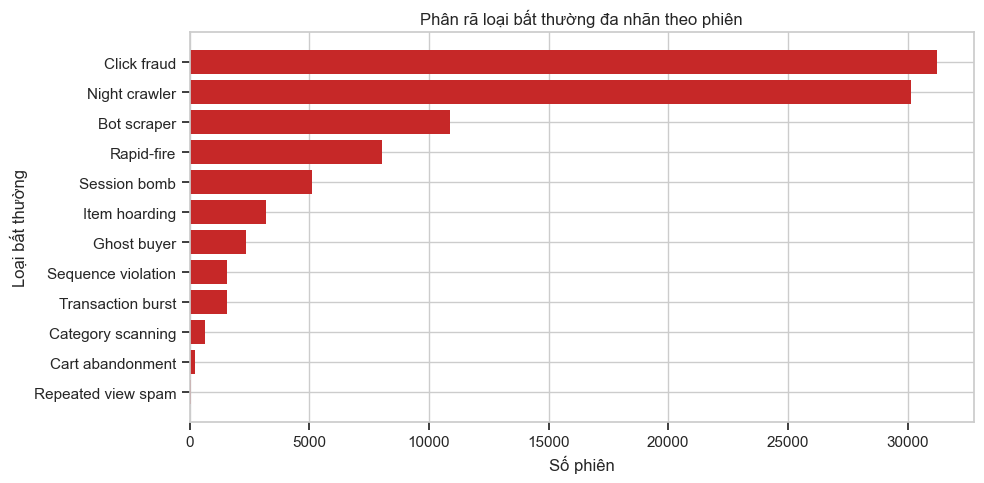

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_rules = rule_summary.sort_values('count', ascending=True)
axes[0].barh(plot_rules['anomaly_type'], plot_rules['count'], color=COLORS['warning'])
axes[0].set_title('Số phiên theo loại bất thường')
axes[0].set_xlabel('Số phiên')

flag_distribution = sessions['total_flags'].value_counts().sort_index()
axes[1].bar(flag_distribution.index.astype(str), flag_distribution.values, color=COLORS['primary'])
axes[1].set_title('Phân phối số loại bất thường mỗi phiên')
axes[1].set_xlabel('Số loại bất thường')
axes[1].set_ylabel('Số phiên')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_rule_breakdown.png', dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
plot_type_breakdown = anomaly_type_breakdown.sort_values('count', ascending=True)
ax.barh(plot_type_breakdown['anomaly_type'], plot_type_breakdown['count'], color=COLORS['anomaly'])
ax.set_title('Phân rã loại bất thường đa nhãn theo phiên')
ax.set_xlabel('Số phiên')
ax.set_ylabel('Loại bất thường')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_anomaly_type_breakdown.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Kiểm tra rò rỉ nhãn theo luật nghiệp vụ

`full_feature_cols` chứa các feature tạo luật để minh họa rule-mimic. `safe_feature_cols` loại feature trực tiếp tạo nhãn và dùng cho bảng metric chính.

Kiểm tra rò rỉ nhãn: tập đặc trưng an toàn đã loại bỏ các đặc trưng trực tiếp tạo ra luật.


,rule,business_condition,rule_input_features,leaked_inputs_in_full_features,inputs_remaining_in_safe_features,n_leaked_inputs
0,BR01_bot_scraper,total_events >= 12 or events_per_minute >= 8 w...,"[total_events, events_per_minute]","[total_events, events_per_minute]",[],2
1,BR02_ghost_buyer,n_transaction > 0 and n_addtocart == 0,"[n_transaction, n_addtocart]","[n_transaction, n_addtocart]",[],2
2,BR03_click_fraud,n_view >= 6 and n_addtocart == 0 and n_transac...,"[n_view, n_addtocart, n_transaction]","[n_view, n_addtocart, n_transaction]",[],3
3,BR04_rapid_fire,rapid_fire_count >= 1 or rapid_ratio >= 0.20 w...,"[rapid_fire_count, rapid_ratio, total_events]","[rapid_fire_count, rapid_ratio, total_events]",[],3
4,BR05_night_crawler,night_ratio >= 0.75 and total_events >= 4,"[night_ratio, night_events, total_events]","[night_ratio, night_events, total_events]",[],3
5,BR06_item_hoarding,max_same_item_atc > 1,[max_same_item_atc],[max_same_item_atc],[],1
6,BR07_session_bomb,unique_items >= 12,[unique_items],[unique_items],[],1
7,BR08_sequence_violation,transaction before prior view/addtocart on sam...,[raw_event_sequence],[],[],0
8,BR09_transaction_burst,n_transaction >= 3,[n_transaction],[n_transaction],[],1
9,BR10_cart_abandonment,n_addtocart >= 10 and n_transaction == 0,"[n_addtocart, n_transaction]","[n_addtocart, n_transaction]",[],2


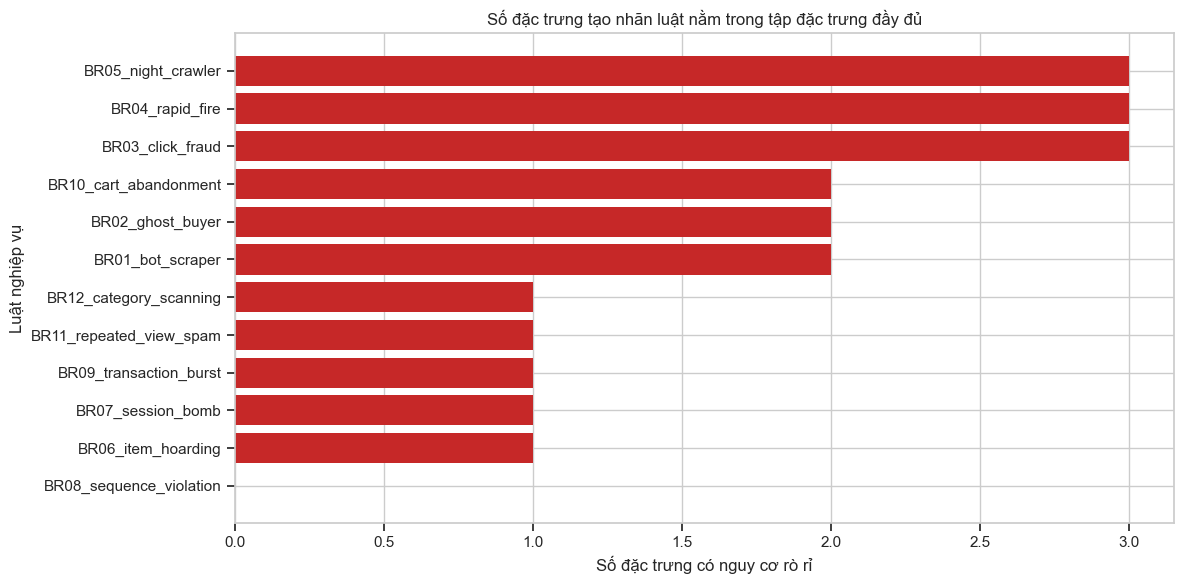

In [8]:
leakage_audit_df = pd.DataFrame([
    {'rule': 'BR01_bot_scraper', 'business_condition': 'total_events >= 12 or events_per_minute >= 8 with enough events', 'rule_input_features': ['total_events', 'events_per_minute']},
    {'rule': 'BR02_ghost_buyer', 'business_condition': 'n_transaction > 0 and n_addtocart == 0', 'rule_input_features': ['n_transaction', 'n_addtocart']},
    {'rule': 'BR03_click_fraud', 'business_condition': 'n_view >= 6 and n_addtocart == 0 and n_transaction == 0', 'rule_input_features': ['n_view', 'n_addtocart', 'n_transaction']},
    {'rule': 'BR04_rapid_fire', 'business_condition': 'rapid_fire_count >= 1 or rapid_ratio >= 0.20 with enough events', 'rule_input_features': ['rapid_fire_count', 'rapid_ratio', 'total_events']},
    {'rule': 'BR05_night_crawler', 'business_condition': 'night_ratio >= 0.75 and total_events >= 4', 'rule_input_features': ['night_ratio', 'night_events', 'total_events']},
    {'rule': 'BR06_item_hoarding', 'business_condition': 'max_same_item_atc > 1', 'rule_input_features': ['max_same_item_atc']},
    {'rule': 'BR07_session_bomb', 'business_condition': 'unique_items >= 12', 'rule_input_features': ['unique_items']},
    {'rule': 'BR08_sequence_violation', 'business_condition': 'transaction before prior view/addtocart on same session-item timeline', 'rule_input_features': ['raw_event_sequence']},
    {'rule': 'BR09_transaction_burst', 'business_condition': 'n_transaction >= 3', 'rule_input_features': ['n_transaction']},
    {'rule': 'BR10_cart_abandonment', 'business_condition': 'n_addtocart >= 10 and n_transaction == 0', 'rule_input_features': ['n_addtocart', 'n_transaction']},
    {'rule': 'BR11_repeated_view_spam', 'business_condition': 'max_same_item_view >= 20', 'rule_input_features': ['max_same_item_view']},
    {'rule': 'BR12_category_scanning', 'business_condition': 'unique_categories >= 20', 'rule_input_features': ['unique_categories']},
])

full_feature_cols = [
    'total_events', 'unique_items', 'session_duration_sec', 'duration_min', 'events_per_minute',
    'n_view', 'n_addtocart', 'n_transaction', 'active_hours', 'unique_event_types',
    'event_type_entropy', 'hour_entropy', 'min_interval_sec', 'mean_interval_sec',
    'median_interval_sec', 'std_interval_sec', 'max_interval_sec', 'rapid_fire_count',
    'night_events', 'peak_events', 'weekend_events', 'view_rate', 'atc_rate', 'buy_rate',
    'night_ratio', 'peak_ratio', 'weekend_ratio', 'rapid_ratio', 'items_per_event',
    'view_to_cart_ratio', 'cart_to_transaction_ratio', 'max_same_item_view', 'max_same_item_atc',
    'unique_categories', 'unique_parent_categories', 'session_start_hour', 'session_dayofweek',
]

safe_feature_cols = [
    'session_duration_sec',
    'active_hours',
    'unique_event_types',
    'event_type_entropy',
    'hour_entropy',
    'mean_interval_sec',
    'median_interval_sec',
    'std_interval_sec',
    'max_interval_sec',
    'peak_events',
    'weekend_events',
    'peak_ratio',
    'weekend_ratio',
    'unique_parent_categories',
    'session_dayofweek',
]

leaky_feature_set = set(full_feature_cols).difference(safe_feature_cols)
leakage_audit_df['leaked_inputs_in_full_features'] = leakage_audit_df['rule_input_features'].apply(
    lambda cols: [col for col in cols if col in leaky_feature_set]
)
leakage_audit_df['inputs_remaining_in_safe_features'] = leakage_audit_df['rule_input_features'].apply(
    lambda cols: [col for col in cols if col in safe_feature_cols]
)
leakage_audit_df['n_leaked_inputs'] = leakage_audit_df['leaked_inputs_in_full_features'].str.len()

print('Kiểm tra rò rỉ nhãn: tập đặc trưng an toàn đã loại bỏ các đặc trưng trực tiếp tạo ra luật.')
display(leakage_audit_df)

if leakage_audit_df['inputs_remaining_in_safe_features'].str.len().sum() != 0:
    raise ValueError('safe_feature_cols vẫn chứa đặc trưng trực tiếp tạo nhãn luật')

fig, ax = plt.subplots(figsize=(12, 6))
plot_leakage = leakage_audit_df.sort_values('n_leaked_inputs', ascending=True)
ax.barh(plot_leakage['rule'], plot_leakage['n_leaked_inputs'], color=COLORS['anomaly'])
ax.set_title('Số đặc trưng tạo nhãn luật nằm trong tập đặc trưng đầy đủ')
ax.set_xlabel('Số đặc trưng có nguy cơ rò rỉ')
ax.set_ylabel('Luật nghiệp vụ')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_leakage_audit.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Chuẩn bị dữ liệu mô hình

Bảng metric chính dùng `safe_feature_cols`; bảng phụ `full_feature_cols` chỉ để chứng minh mô hình học lại luật khi có leakage.

Dữ liệu supervised được chia theo tỉ lệ **60% train - 20% validation - 20% test**. Validation dùng để chọn ngưỡng dự đoán/anomaly score, còn test dùng làm kết quả báo cáo cuối.


In [9]:
def build_clean_feature_matrix(source_dataframe, columns):
    feature_matrix = source_dataframe[columns].replace([np.inf, -np.inf], np.nan).fillna(0).astype('float32')
    if feature_matrix.isna().any().any():
        raise ValueError('Ma trận đặc trưng vẫn còn NaN sau khi xử lý')
    if not np.isfinite(feature_matrix.to_numpy()).all():
        raise ValueError('Ma trận đặc trưng vẫn còn inf sau khi xử lý')
    return feature_matrix

features_full = build_clean_feature_matrix(sessions, full_feature_cols)
features_safe = build_clean_feature_matrix(sessions, safe_feature_cols)
labels = sessions['is_anomaly_rule'].astype(int)

if labels.nunique() != 2:
    raise ValueError('Nhãn is_anomaly_rule phải có đủ 2 lớp')

all_indices = np.arange(len(labels))
if MAX_SUPERVISED_ROWS is not None and len(labels) > MAX_SUPERVISED_ROWS:
    supervised_indices, _ = train_test_split(
        all_indices,
        train_size=MAX_SUPERVISED_ROWS,
        random_state=RANDOM_STATE,
        stratify=labels,
    )
else:
    supervised_indices = all_indices

visitor_ids_all = sessions['visitorid'].to_numpy()
visitor_ids_supervised = visitor_ids_all[supervised_indices]
labels_supervised = labels.iloc[supervised_indices].to_numpy()

group_splitter_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_validation_positions, test_positions = next(group_splitter_test.split(supervised_indices, labels_supervised, visitor_ids_supervised))
train_validation_indices = supervised_indices[train_validation_positions]
test_indices = supervised_indices[test_positions]

visitor_ids_train_validation = visitor_ids_all[train_validation_indices]
labels_train_validation = labels.iloc[train_validation_indices].to_numpy()
group_splitter_validation = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_positions, validation_positions = next(group_splitter_validation.split(train_validation_indices, labels_train_validation, visitor_ids_train_validation))
train_indices = train_validation_indices[train_positions]
validation_indices = train_validation_indices[validation_positions]

features_safe_train = features_safe.iloc[train_indices]
features_safe_validation = features_safe.iloc[validation_indices]
features_safe_test = features_safe.iloc[test_indices]
features_full_train = features_full.iloc[train_indices]
features_full_validation = features_full.iloc[validation_indices]
features_full_test = features_full.iloc[test_indices]
labels_train = labels.iloc[train_indices]
labels_validation = labels.iloc[validation_indices]
labels_test = labels.iloc[test_indices]

safe_feature_scaler = RobustScaler()
safe_feature_scaler.fit(features_safe_train)
features_safe_scaled = safe_feature_scaler.transform(features_safe).astype('float32')
features_safe_scaled_train = features_safe_scaled[train_indices]
features_safe_scaled_validation = features_safe_scaled[validation_indices]
features_safe_scaled_test = features_safe_scaled[test_indices]

full_feature_scaler = RobustScaler()
full_feature_scaler.fit(features_full_train)
features_full_scaled = full_feature_scaler.transform(features_full).astype('float32')

print(f'Toàn bộ session profile: {len(features_safe):,} dòng')
print(f'Mẫu supervised train/validation/test: {len(supervised_indices):,} dòng')
print(f'Train: {len(train_indices):,}; Validation: {len(validation_indices):,}; Test: {len(test_indices):,}')
print(f'Tỉ lệ anomaly trong toàn bộ session: {labels.mean() * 100:.2f}%')
print(f'Tỉ lệ anomaly trong train: {labels_train.mean() * 100:.2f}%')
print(f'Tỉ lệ anomaly trong validation: {labels_validation.mean() * 100:.2f}%')
print(f'Tỉ lệ anomaly trong test: {labels_test.mean() * 100:.2f}%')
print(f'Số safe features: {len(safe_feature_cols)}; Số full features: {len(full_feature_cols)}')

visitors_train = set(visitor_ids_all[train_indices])
visitors_validation = set(visitor_ids_all[validation_indices])
visitors_test = set(visitor_ids_all[test_indices])
overlap_train_validation = visitors_train & visitors_validation
overlap_train_test = visitors_train & visitors_test
overlap_validation_test = visitors_validation & visitors_test
print(f'Visitor train/validation/test: {len(visitors_train):,} / {len(visitors_validation):,} / {len(visitors_test):,}')
print(f'Trùng visitor train-validation: {len(overlap_train_validation)}; train-test: {len(overlap_train_test)}; validation-test: {len(overlap_validation_test)}')
assert not (overlap_train_validation or overlap_train_test or overlap_validation_test), 'Vẫn còn visitor bị rò rỉ giữa các tập!'
print('OK: không có visitor nào bị rò rỉ giữa train/validation/test (tách nhóm theo visitorid).')

Toàn bộ session profile: 1,761,675 dòng
Mẫu supervised train/validation/test: 1,761,675 dòng
Train: 1,056,863; Validation: 352,486; Test: 352,326
Tỉ lệ anomaly trong toàn bộ session: 3.51%
Tỉ lệ anomaly trong train: 3.51%
Tỉ lệ anomaly trong validation: 3.48%
Tỉ lệ anomaly trong test: 3.55%
Số safe features: 15; Số full features: 37
Visitor train/validation/test: 844,548 / 281,516 / 281,516
Trùng visitor train-validation: 0; train-test: 0; validation-test: 0
OK: không có visitor nào bị rò rỉ giữa train/validation/test (tách nhóm theo visitorid).


In [10]:
BASELINE_EVALUATION = 'Baseline so với nhãn giả phiên'
MAIN_SUPERVISED_EVALUATION = 'Mô hình giám sát chính so với nhãn giả phiên'
RULE_MIMIC_EVALUATION = 'Rule-mimic / agreement with session business rules'
UNSUPERVISED_EVALUATION = 'Unsupervised overlap with session pseudo-label'
SANITY_CHECK_EVALUATION = 'Sanity check: shuffled labels should fail'

evaluation_records = []
confusion_prediction_sets = {}

def choose_best_threshold(true_labels, scores, label, metric='f1'):
    true_labels = np.asarray(true_labels).astype(int)
    scores = np.asarray(scores, dtype='float64')
    if len(scores) == 0 or len(np.unique(scores)) <= 1:
        print(f'{label}: điểm số không đủ biến thiên, dùng ngưỡng mặc định 0.5')
        return 0.5

    candidate_thresholds = np.unique(np.r_[0.5, np.quantile(scores, np.linspace(0.01, 0.99, 99))])
    best_threshold = 0.5
    best_value = -1.0
    best_precision = -1.0
    best_recall = -1.0

    for threshold in candidate_thresholds:
        predictions = (scores >= threshold).astype(int)
        if metric == 'recall':
            value = recall_score(true_labels, predictions, zero_division=0)
        elif metric == 'precision':
            value = precision_score(true_labels, predictions, zero_division=0)
        else:
            value = f1_score(true_labels, predictions, zero_division=0)
        precision = precision_score(true_labels, predictions, zero_division=0)
        recall = recall_score(true_labels, predictions, zero_division=0)

        if (
            value > best_value
            or (np.isclose(value, best_value) and precision > best_precision)
            or (np.isclose(value, best_value) and np.isclose(precision, best_precision) and recall > best_recall)
        ):
            best_threshold = float(threshold)
            best_value = float(value)
            best_precision = float(precision)
            best_recall = float(recall)

    print(
        f'{label}: chọn ngưỡng={best_threshold:.4f} trên validation '
        f'({metric}={best_value:.4f}, precision={best_precision:.4f}, recall={best_recall:.4f})'
    )
    return best_threshold

def record_evaluation(model_name, feature_set, evaluation_type, split,
                      true_labels, predictions, scores=None,
                      threshold=np.nan, store_confusion=True):
    true_labels = np.asarray(true_labels).astype(int)
    predictions = np.asarray(predictions).astype(int)

    record = {
        'model': model_name,
        'feature_set': feature_set,
        'evaluation_type': evaluation_type,
        'split': split,
        'threshold': threshold,
        'accuracy': accuracy_score(true_labels, predictions),
        'precision': precision_score(true_labels, predictions, zero_division=0),
        'recall': recall_score(true_labels, predictions, zero_division=0),
        'f1_score': f1_score(true_labels, predictions, zero_division=0),
        'roc_auc': np.nan,
        'pr_auc': np.nan,
        'support_anomaly': int(true_labels.sum()),
        'predicted_anomaly': int(predictions.sum()),
    }

    if scores is not None and len(np.unique(true_labels)) == 2:
        try:
            record['roc_auc'] = roc_auc_score(true_labels, scores)
        except ValueError:
            record['roc_auc'] = np.nan
        try:
            record['pr_auc'] = average_precision_score(true_labels, scores)
        except ValueError:
            record['pr_auc'] = np.nan

    evaluation_records.append(record)
    confusion_key = f'{model_name} ({feature_set})'
    if store_confusion:
        confusion_prediction_sets[confusion_key] = {
            'y_true': true_labels,
            'y_pred': predictions,
            'evaluation_type': evaluation_type,
            'split': split,
        }

    print()
    print(f'{model_name} - {feature_set} - {evaluation_type} - {split}')
    print(classification_report(true_labels, predictions, target_names=['Normal', 'Anomaly'], zero_division=0))

def train_and_evaluate_supervised_model(model, model_name,
                                        features_train, labels_train,
                                        features_validation, labels_validation,
                                        features_test, labels_test,
                                        features_all,
                                        feature_set='safe_features',
                                        evaluation_type=MAIN_SUPERVISED_EVALUATION,
                                        store_test_confusion=True):
    model.fit(features_train, labels_train)

    validation_scores = model.predict_proba(features_validation)[:, 1]
    threshold = choose_best_threshold(labels_validation, validation_scores, f'{model_name} ({feature_set})')

    validation_predictions = (validation_scores >= threshold).astype(int)
    record_evaluation(model_name, feature_set, evaluation_type, 'validation',
                      labels_validation, validation_predictions, validation_scores,
                      threshold=threshold, store_confusion=False)

    test_scores = model.predict_proba(features_test)[:, 1]
    test_predictions = (test_scores >= threshold).astype(int)
    record_evaluation(model_name, feature_set, evaluation_type, 'test',
                      labels_test, test_predictions, test_scores,
                      threshold=threshold, store_confusion=store_test_confusion)

    scores_all_sessions = model.predict_proba(features_all)[:, 1]
    predictions_all_sessions = (scores_all_sessions >= threshold).astype(int)
    return model, threshold, scores_all_sessions, predictions_all_sessions

In [11]:
# ============================================================
# HẠ TẦNG ĐA NHÃN (MULTI-LABEL) DÙNG CHUNG CHO 4 THÀNH VIÊN GIÁM SÁT
# ------------------------------------------------------------
# Mỗi thành viên huấn luyện 1 mô hình ĐA NHÃN: dự đoán session thuộc
# LOẠI bất thường nào trong 12 loại BR01..BR12 (một session có thể nhiều loại).
# Vẫn chỉ dùng safe_feature_cols -> mô hình phải HỌC nhận diện từ hành vi,
# KHÔNG chép lại luật. Đây là kết quả báo cáo CHÍNH (trung thực).
# ============================================================
from sklearn.multioutput import MultiOutputClassifier

MULTILABEL_MAIN_EVALUATION = 'Đa nhãn - safe features (kết quả chính)'
MULTILABEL_RULE_MIMIC_EVALUATION = 'Đa nhãn - full features (học lại luật / leakage)'
MULTILABEL_SANITY_EVALUATION = 'Đa nhãn - sanity check: tráo nhãn phải tệ đi'
MULTILABEL_BASELINE_EVALUATION = 'Đa nhãn - baseline ngẫu nhiên'

MIN_LABEL_POSITIVES = 30  # loại quá hiếm trong train -> không mô hình hoá (đánh giá không tin cậy)

# Ma trận nhãn 12 cột: mỗi cột = 1 loại bất thường
labels_multi = sessions[flag_cols].astype(int)
labels_multi_train = labels_multi.iloc[train_indices]
labels_multi_validation = labels_multi.iloc[validation_indices]
labels_multi_test = labels_multi.iloc[test_indices]

# Chỉ mô hình hoá loại có đủ 2 lớp và đủ mẫu dương trong train
model_label_cols = [
    c for c in flag_cols
    if labels_multi_train[c].nunique() == 2 and int(labels_multi_train[c].sum()) >= MIN_LABEL_POSITIVES
]
dropped_label_cols = [c for c in flag_cols if c not in model_label_cols]
model_label_names = [anomaly_type_map[c] for c in model_label_cols]

labels_multi_train_model = labels_multi_train[model_label_cols]
labels_multi_validation_model = labels_multi_validation[model_label_cols]
labels_multi_test_model = labels_multi_test[model_label_cols]
labels_multi_all_model = labels_multi[model_label_cols]

print(f'Số loại được mô hình hoá: {len(model_label_cols)}/{len(flag_cols)}')
if dropped_label_cols:
    print('Loại bị bỏ vì quá hiếm trong train:', [anomaly_type_map[c] for c in dropped_label_cols])
print('Số session dương theo từng loại (train / test):')
_support = pd.concat([
    labels_multi_train_model.sum().rename('train_positive'),
    labels_multi_test_model.sum().rename('test_positive'),
], axis=1)
_support.index = [anomaly_type_map[c] for c in model_label_cols]
display(_support)

# Bộ thu thập kết quả
multilabel_evaluation_records = []
per_label_records = []
multilabel_confusion_sets = {}
binary_overlap_records = []


def proba_matrix(model, features, n_labels):
    """Trả về ma trận xác suất dương (n_samples x n_labels) cho mọi loại mô hình đa nhãn."""
    probabilities = model.predict_proba(features)
    if not isinstance(probabilities, list):
        probabilities = [probabilities]
    columns = []
    for proba in probabilities:
        proba = np.asarray(proba)
        if proba.ndim == 2 and proba.shape[1] == 2:
            columns.append(proba[:, 1])
        elif proba.ndim == 2 and proba.shape[1] == 1:
            columns.append(proba[:, 0])
        else:
            columns.append(np.zeros(proba.shape[0]))
    score_matrix = np.column_stack(columns)
    if score_matrix.shape[1] != n_labels:
        raise ValueError('Số cột xác suất không khớp số nhãn')
    return score_matrix


def choose_thresholds_per_label(true_matrix, score_matrix, label, max_pos_rate_multiple=3.0):
    """Chọn ngưỡng tối đa F1 RIÊNG cho từng nhãn trên validation, có chặn over-predict."""
    true_matrix = np.asarray(true_matrix).astype(int)
    score_matrix = np.asarray(score_matrix, dtype='float64')
    n_labels = score_matrix.shape[1]
    thresholds = np.full(n_labels, 0.5)
    for j in range(n_labels):
        scores = score_matrix[:, j]
        truths = true_matrix[:, j]
        if len(np.unique(scores)) <= 1 or len(np.unique(truths)) <= 1:
            thresholds[j] = 0.5
            continue
        base_rate = float(truths.mean())
        cap = min(1.0, max(base_rate * max_pos_rate_multiple, base_rate + 0.005))
        candidates = np.unique(np.r_[0.5, np.quantile(scores, np.linspace(0.01, 0.999, 99))])
        best_threshold, best_f1 = None, -1.0
        for t in candidates:
            predictions = (scores >= t).astype(int)
            if predictions.mean() > cap:
                continue
            value = f1_score(truths, predictions, zero_division=0)
            if value > best_f1:
                best_f1, best_threshold = value, float(t)
        if best_threshold is None:
            best_threshold = float(candidates.max())
        thresholds[j] = best_threshold
    print(f'{label}: đã chọn ngưỡng riêng cho {n_labels} nhãn (có ràng buộc tỉ lệ dương)')
    return thresholds


def predict_with_thresholds(score_matrix, thresholds):
    return (np.asarray(score_matrix) >= np.asarray(thresholds)).astype(int)


def record_multilabel(model_name, feature_set, evaluation_type, split,
                      true_matrix, prediction_matrix, label_names,
                      score_matrix=None, store_confusion=True):
    true_matrix = np.asarray(true_matrix).astype(int)
    prediction_matrix = np.asarray(prediction_matrix).astype(int)

    macro_f1 = f1_score(true_matrix, prediction_matrix, average='macro', zero_division=0)
    micro_f1 = f1_score(true_matrix, prediction_matrix, average='micro', zero_division=0)
    weighted_f1 = f1_score(true_matrix, prediction_matrix, average='weighted', zero_division=0)
    macro_precision = precision_score(true_matrix, prediction_matrix, average='macro', zero_division=0)
    macro_recall = recall_score(true_matrix, prediction_matrix, average='macro', zero_division=0)
    micro_precision = precision_score(true_matrix, prediction_matrix, average='micro', zero_division=0)
    micro_recall = recall_score(true_matrix, prediction_matrix, average='micro', zero_division=0)
    hamming = hamming_loss(true_matrix, prediction_matrix)
    subset_accuracy = accuracy_score(true_matrix, prediction_matrix)

    macro_pr_auc = np.nan
    per_label_pr_auc = [np.nan] * len(label_names)
    if score_matrix is not None:
        score_matrix = np.asarray(score_matrix, dtype='float64')
        aps = []
        for j in range(len(label_names)):
            if len(np.unique(true_matrix[:, j])) == 2:
                ap = average_precision_score(true_matrix[:, j], score_matrix[:, j])
                per_label_pr_auc[j] = ap
                aps.append(ap)
        macro_pr_auc = float(np.mean(aps)) if aps else np.nan

    multilabel_evaluation_records.append({
        'model': model_name, 'feature_set': feature_set, 'evaluation_type': evaluation_type, 'split': split,
        'macro_f1': macro_f1, 'micro_f1': micro_f1, 'weighted_f1': weighted_f1,
        'macro_precision': macro_precision, 'macro_recall': macro_recall,
        'micro_precision': micro_precision, 'micro_recall': micro_recall,
        'macro_pr_auc': macro_pr_auc, 'hamming_loss': hamming, 'subset_accuracy': subset_accuracy,
        'n_labels': len(label_names), 'support_total': int(true_matrix.sum()),
        'predicted_total': int(prediction_matrix.sum()),
    })

    precision, recall, f1_values, support = precision_recall_fscore_support(
        true_matrix, prediction_matrix, average=None, zero_division=0)
    for j, name in enumerate(label_names):
        per_label_records.append({
            'model': model_name, 'feature_set': feature_set, 'split': split, 'label': name,
            'precision': precision[j], 'recall': recall[j], 'f1_score': f1_values[j],
            'pr_auc': per_label_pr_auc[j], 'support': int(support[j]),
        })

    if store_confusion:
        multilabel_confusion_sets[f'{model_name} ({feature_set})'] = {
            'y_true_any': (true_matrix.max(axis=1) > 0).astype(int),
            'y_pred_any': (prediction_matrix.max(axis=1) > 0).astype(int),
            'split': split,
        }

    print()
    print(f'{model_name} - {feature_set} - {evaluation_type} - {split}')
    print(f'macro-F1={macro_f1:.4f} | micro-F1={micro_f1:.4f} | macro-PR-AUC={macro_pr_auc:.4f} | '
          f'Hamming={hamming:.4f} | subset-acc={subset_accuracy:.4f}')
    print(classification_report(true_matrix, prediction_matrix, target_names=label_names, zero_division=0))


def record_binary_overlap(model_name, feature_set, split, true_binary, prediction_binary):
    """Quy về nhị phân 'có bất thường hay không' để so chung với Isolation Forest."""
    true_binary = np.asarray(true_binary).astype(int)
    prediction_binary = np.asarray(prediction_binary).astype(int)
    binary_overlap_records.append({
        'model': model_name, 'feature_set': feature_set, 'split': split,
        'precision': precision_score(true_binary, prediction_binary, zero_division=0),
        'recall': recall_score(true_binary, prediction_binary, zero_division=0),
        'f1_score': f1_score(true_binary, prediction_binary, zero_division=0),
        'accuracy': accuracy_score(true_binary, prediction_binary),
        'support_anomaly': int(true_binary.sum()), 'predicted_anomaly': int(prediction_binary.sum()),
    })


def train_and_evaluate_multilabel(model, model_name,
                                  features_train, labels_train_matrix,
                                  features_validation, labels_validation_matrix,
                                  features_test, labels_test_matrix,
                                  features_all, label_names,
                                  feature_set='safe_features',
                                  evaluation_type=MULTILABEL_MAIN_EVALUATION,
                                  store_test_confusion=True):
    n_labels = len(label_names)
    model.fit(features_train, labels_train_matrix)

    validation_scores = proba_matrix(model, features_validation, n_labels)
    thresholds = choose_thresholds_per_label(
        labels_validation_matrix.to_numpy(), validation_scores, f'{model_name} ({feature_set})')

    validation_predictions = predict_with_thresholds(validation_scores, thresholds)
    record_multilabel(model_name, feature_set, evaluation_type, 'validation',
                      labels_validation_matrix.to_numpy(), validation_predictions,
                      label_names, score_matrix=validation_scores, store_confusion=False)

    test_scores = proba_matrix(model, features_test, n_labels)
    test_predictions = predict_with_thresholds(test_scores, thresholds)
    record_multilabel(model_name, feature_set, evaluation_type, 'test',
                      labels_test_matrix.to_numpy(), test_predictions,
                      label_names, score_matrix=test_scores, store_confusion=store_test_confusion)

    all_scores = proba_matrix(model, features_all, n_labels)
    all_predictions = predict_with_thresholds(all_scores, thresholds)
    return model, thresholds, all_scores, all_predictions


def predicted_types_string(prediction_matrix, label_names):
    names = np.array(label_names, dtype=object)
    output = []
    for row in np.asarray(prediction_matrix).astype(bool):
        output.append(', '.join(names[row].tolist()) if row.any() else 'Normal')
    return output


def get_feature_importances(model):
    """Độ quan trọng đặc trưng cho cả mô hình đa nhãn (trung bình qua các bộ con) lẫn native."""
    if hasattr(model, 'estimators_') and not hasattr(model, 'feature_importances_'):
        importances = [est.feature_importances_ for est in model.estimators_ if hasattr(est, 'feature_importances_')]
        return np.mean(importances, axis=0)
    return model.feature_importances_


Số loại được mô hình hoá: 12/12
Số session dương theo từng loại (train / test):


,train_positive,test_positive
Bot scraper,6577,2168
Ghost buyer,1407,471
Click fraud,18697,6319
Rapid-fire,4913,1578
Night crawler,18091,6111
Item hoarding,1949,662
Session bomb,3063,1022
Sequence violation,995,286
Transaction burst,941,339
Cart abandonment,143,36


## 7. Baseline và mô hình ĐA NHÃN của từng thành viên (safe feature set)

Mỗi thành viên giám sát huấn luyện một mô hình **đa nhãn (multi-label)**: dự đoán session thuộc **loại** bất thường nào trong 12 loại nghiệp vụ (BR01–BR12). Một session có thể đồng thời thuộc nhiều loại, nên dùng chiến lược **One-vs-Rest**.

Tất cả huấn luyện trên `train`, chọn ngưỡng riêng cho từng loại trên `validation`, và chỉ dùng `test` để báo cáo. Đặc trưng dùng là `safe_feature_cols` (đã loại biến trực tiếp sinh luật) để mô hình **học phát hiện** thay vì **chép lại luật** — nên F1 khác nhau theo từng loại là điều bình thường và trung thực.


In [ ]:
# Baseline ngẫu nhiên đa nhãn: mốc thấp nhất để các mô hình thật phải vượt qua.
dummy_model = MultiOutputClassifier(
    DummyClassifier(strategy='stratified', random_state=RANDOM_STATE), n_jobs=-1)
dummy_model.fit(features_safe_train, labels_multi_train_model)

n_lab = len(model_label_cols)
dummy_validation_scores = proba_matrix(dummy_model, features_safe_validation, n_lab)
dummy_validation_predictions = predict_with_thresholds(dummy_validation_scores, np.full(n_lab, 0.5))
record_multilabel('Dummy baseline', 'safe_features', MULTILABEL_BASELINE_EVALUATION, 'validation',
                  labels_multi_validation_model.to_numpy(), dummy_validation_predictions,
                  model_label_names, score_matrix=dummy_validation_scores, store_confusion=False)

dummy_test_scores = proba_matrix(dummy_model, features_safe_test, n_lab)
dummy_test_predictions = predict_with_thresholds(dummy_test_scores, np.full(n_lab, 0.5))
record_multilabel('Dummy baseline', 'safe_features', MULTILABEL_BASELINE_EVALUATION, 'test',
                  labels_multi_test_model.to_numpy(), dummy_test_predictions,
                  model_label_names, score_matrix=dummy_test_scores, store_confusion=False)


<a id="section-xgboost"></a>

### Đình Tuấn - XGBoost (đa nhãn — dự đoán loại bất thường)

In [ ]:
def make_xgboost_model(n_estimators=120):
    return XGBClassifier(
        n_estimators=n_estimators,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.85,
        colsample_bytree=0.85,
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

# One-vs-Rest: 1 bộ XGBoost cho mỗi loại bất thường (mất cân bằng xử lý bằng ngưỡng riêng).
xgboost_model = MultiOutputClassifier(make_xgboost_model(n_estimators=120), n_jobs=-1)
(
    xgboost_model,
    xgboost_thresholds,
    xgboost_scores_all,
    xgboost_predictions_all,
) = train_and_evaluate_multilabel(
    model=xgboost_model, model_name='XGBoost',
    features_train=features_safe_train, labels_train_matrix=labels_multi_train_model,
    features_validation=features_safe_validation, labels_validation_matrix=labels_multi_validation_model,
    features_test=features_safe_test, labels_test_matrix=labels_multi_test_model,
    features_all=features_safe, label_names=model_label_names,
    feature_set='safe_features', evaluation_type=MULTILABEL_MAIN_EVALUATION,
)

# Quy về cấp session để dùng cho report tổng hợp và so sánh nhị phân
sessions['xgboost_pred'] = xgboost_predictions_all.max(axis=1)
sessions['xgboost_score'] = xgboost_scores_all.max(axis=1)
sessions['xgboost_n_pred_types'] = xgboost_predictions_all.sum(axis=1)
sessions['xgboost_pred_types'] = predicted_types_string(xgboost_predictions_all, model_label_names)

# Loại dự đoán đại diện cho export (lấy từ XGBoost - thành viên Đình Tuấn)
sessions['predicted_anomaly_types'] = sessions['xgboost_pred_types']
sessions['predicted_anomaly_type_count'] = sessions['xgboost_n_pred_types']

record_binary_overlap('XGBoost', 'safe_features', 'test',
                      labels_test.to_numpy(), xgboost_predictions_all[test_indices].max(axis=1))


### Lê Văn Anh - Decision Tree (đa nhãn — dự đoán loại bất thường)

In [ ]:
# Một cây cho mỗi loại (One-vs-Rest) trên safe features.
decision_tree_model = MultiOutputClassifier(
    DecisionTreeClassifier(max_depth=12, min_samples_leaf=20, class_weight='balanced',
                           random_state=RANDOM_STATE), n_jobs=-1)
(
    decision_tree_model,
    decision_tree_thresholds,
    decision_tree_scores_all,
    decision_tree_predictions_all,
) = train_and_evaluate_multilabel(
    model=decision_tree_model, model_name='Decision Tree',
    features_train=features_safe_train, labels_train_matrix=labels_multi_train_model,
    features_validation=features_safe_validation, labels_validation_matrix=labels_multi_validation_model,
    features_test=features_safe_test, labels_test_matrix=labels_multi_test_model,
    features_all=features_safe, label_names=model_label_names,
    feature_set='safe_features', evaluation_type=MULTILABEL_MAIN_EVALUATION,
)
sessions['decision_tree_pred'] = decision_tree_predictions_all.max(axis=1)
sessions['decision_tree_score'] = decision_tree_scores_all.max(axis=1)
sessions['decision_tree_n_pred_types'] = decision_tree_predictions_all.sum(axis=1)
sessions['decision_tree_pred_types'] = predicted_types_string(decision_tree_predictions_all, model_label_names)
record_binary_overlap('Decision Tree', 'safe_features', 'test',
                      labels_test.to_numpy(), decision_tree_predictions_all[test_indices].max(axis=1))

# MINH HOẠ: cây đơn nhãn (is_anomaly) chỉ để xem các nhánh quyết định trên safe features.
illustration_tree = DecisionTreeClassifier(
    max_depth=4, min_samples_leaf=100, class_weight='balanced', random_state=RANDOM_STATE)
illustration_tree.fit(features_safe_train, labels_train)
fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    illustration_tree,
    feature_names=safe_feature_cols,
    class_names=['Bình thường', 'Bất thường'],
    filled=True, rounded=True, max_depth=3, fontsize=8, ax=ax,
)
ax.set_title('MINH HOẠ: cây quyết định đơn nhãn (is_anomaly) trên đặc trưng phiên an toàn')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_decision_tree.png', dpi=160, bbox_inches='tight')
plt.show()


<a id="section-random-forest"></a>

### Tuấn Anh - Random Forest (đa nhãn — dự đoán loại bất thường)

In [ ]:
# Random Forest hỗ trợ đa nhãn gốc (truyền y 2D), có feature_importances_ trực tiếp.
random_forest_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=16,
    min_samples_leaf=20,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
(
    random_forest_model,
    random_forest_thresholds,
    random_forest_scores_all,
    random_forest_predictions_all,
) = train_and_evaluate_multilabel(
    model=random_forest_model, model_name='Random Forest',
    features_train=features_safe_train, labels_train_matrix=labels_multi_train_model,
    features_validation=features_safe_validation, labels_validation_matrix=labels_multi_validation_model,
    features_test=features_safe_test, labels_test_matrix=labels_multi_test_model,
    features_all=features_safe, label_names=model_label_names,
    feature_set='safe_features', evaluation_type=MULTILABEL_MAIN_EVALUATION,
)
sessions['random_forest_pred'] = random_forest_predictions_all.max(axis=1)
sessions['random_forest_score'] = random_forest_scores_all.max(axis=1)
sessions['random_forest_n_pred_types'] = random_forest_predictions_all.sum(axis=1)
sessions['random_forest_pred_types'] = predicted_types_string(random_forest_predictions_all, model_label_names)
record_binary_overlap('Random Forest', 'safe_features', 'test',
                      labels_test.to_numpy(), random_forest_predictions_all[test_indices].max(axis=1))


### Thủy - LightGBM (đa nhãn — dự đoán loại bất thường)


In [ ]:
def make_lightgbm_model(n_estimators=160):
    return LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        objective='binary',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        reg_lambda=1.0,
        verbosity=-1,
        force_col_wise=True,
    )

lightgbm_model = MultiOutputClassifier(make_lightgbm_model(n_estimators=160), n_jobs=-1)
(
    lightgbm_model,
    lightgbm_thresholds,
    lightgbm_scores_all,
    lightgbm_predictions_all,
) = train_and_evaluate_multilabel(
    model=lightgbm_model, model_name='LightGBM',
    features_train=features_safe_train, labels_train_matrix=labels_multi_train_model,
    features_validation=features_safe_validation, labels_validation_matrix=labels_multi_validation_model,
    features_test=features_safe_test, labels_test_matrix=labels_multi_test_model,
    features_all=features_safe, label_names=model_label_names,
    feature_set='safe_features', evaluation_type=MULTILABEL_MAIN_EVALUATION,
)
sessions['lightgbm_pred'] = lightgbm_predictions_all.max(axis=1)
sessions['lightgbm_score'] = lightgbm_scores_all.max(axis=1)
sessions['lightgbm_n_pred_types'] = lightgbm_predictions_all.sum(axis=1)
sessions['lightgbm_pred_types'] = predicted_types_string(lightgbm_predictions_all, model_label_names)
record_binary_overlap('LightGBM', 'safe_features', 'test',
                      labels_test.to_numpy(), lightgbm_predictions_all[test_indices].max(axis=1))


## 8. Bảng phụ: mô hình ĐA NHÃN học lại luật bằng full feature set

Phần này cố tình giữ các biến sinh luật để chứng minh vì sao chỉ số có thể "quá đẹp" khi bị leakage: macro-F1 của cả 4 thuật toán sẽ tăng vọt gần tuyệt đối. So với bảng chính (safe features), khoảng chênh này chính là phần "chép lại luật" chứ không phải năng lực phát hiện thật.


In [ ]:
# Đối chứng leakage (đa nhãn): train lại 4 thuật toán trên FULL features (giữ biến sinh luật).
# macro-F1 sẽ cao bất thường -> chứng minh điểm "quá đẹp" đến từ việc mô hình NHÌN THẤY biến
# sinh luật (chép lại luật), KHÔNG phải năng lực phát hiện thật.
for _name, _ctor in [
    ('XGBoost', lambda: MultiOutputClassifier(make_xgboost_model(n_estimators=120), n_jobs=-1)),
    ('LightGBM', lambda: MultiOutputClassifier(make_lightgbm_model(n_estimators=160), n_jobs=-1)),
    ('Decision Tree', lambda: MultiOutputClassifier(
        DecisionTreeClassifier(max_depth=12, min_samples_leaf=20, class_weight='balanced',
                               random_state=RANDOM_STATE), n_jobs=-1)),
    ('Random Forest', lambda: RandomForestClassifier(
        n_estimators=120, max_depth=16, min_samples_leaf=20, class_weight='balanced_subsample',
        random_state=RANDOM_STATE, n_jobs=-1)),
]:
    train_and_evaluate_multilabel(
        model=_ctor(), model_name=_name,
        features_train=features_full_train, labels_train_matrix=labels_multi_train_model,
        features_validation=features_full_validation, labels_validation_matrix=labels_multi_validation_model,
        features_test=features_full_test, labels_test_matrix=labels_multi_test_model,
        features_all=features_full, label_names=model_label_names,
        feature_set='full_features', evaluation_type=MULTILABEL_RULE_MIMIC_EVALUATION,
        store_test_confusion=False,
    )


## 9. Shuffle-label sanity check (đa nhãn)

Tráo (permute) các dòng nhãn train để phá liên kết đặc trưng–nhãn. Nếu pipeline không còn lỗi rò rỉ nghiêm trọng, macro-F1 trên test phải sụp về gần mức baseline ngẫu nhiên.


In [ ]:
# Sanity check đa nhãn: tráo (permute) các DÒNG nhãn train để phá liên kết đặc trưng-nhãn.
# Nếu pipeline đúng, macro-F1 trên test phải SỤP về gần baseline.
rng = np.random.default_rng(RANDOM_STATE)
shuffle_perm = rng.permutation(len(labels_multi_train_model))
shuffled_labels_multi_train = labels_multi_train_model.iloc[shuffle_perm]

xgboost_shuffle_model = MultiOutputClassifier(make_xgboost_model(n_estimators=80), n_jobs=-1)
train_and_evaluate_multilabel(
    model=xgboost_shuffle_model, model_name='XGBoost (shuffled labels)',
    features_train=features_safe_train, labels_train_matrix=shuffled_labels_multi_train,
    features_validation=features_safe_validation, labels_validation_matrix=labels_multi_validation_model,
    features_test=features_safe_test, labels_test_matrix=labels_multi_test_model,
    features_all=features_safe, label_names=model_label_names,
    feature_set='safe_features', evaluation_type=MULTILABEL_SANITY_EVALUATION,
    store_test_confusion=False,
)


## 10. Feature importance trên safe session feature set

In [ ]:
def top_feature_importances(model, feature_names, model_name, top_n=12):
    frame = pd.DataFrame({'feature': feature_names, 'importance': get_feature_importances(model), 'model': model_name})
    return frame.sort_values('importance', ascending=False).head(top_n)

importance_models = [
    ('XGBoost', xgboost_model, COLORS['secondary']),
    ('LightGBM', lightgbm_model, COLORS['warning']),
    ('Random Forest', random_forest_model, COLORS['primary']),
]
feature_importances = pd.concat(
    [top_feature_importances(model, safe_feature_cols, model_name) for model_name, model, _ in importance_models],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, (model_name, _, color) in zip(axes, importance_models):
    subset = feature_importances[feature_importances['model'] == model_name].sort_values('importance', ascending=True)
    ax.barh(subset['feature'], subset['importance'], color=color)
    ax.set_title(f'Độ quan trọng đặc trưng (đa nhãn, trung bình 12 loại) - {model_name}')
    ax.set_xlabel('Độ quan trọng')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

display(feature_importances)


<a id="section-isolation-forest"></a>

## 11. Đức Anh - Isolation Forest

Isolation Forest fit trên train không cần nhãn. Validation dùng để chọn ngưỡng anomaly score, sau đó test dùng để báo cáo overlap với pseudo-label.


In [ ]:
if IFOREST_TRAIN_ROWS is not None and len(train_indices) > IFOREST_TRAIN_ROWS:
    rng = np.random.default_rng(RANDOM_STATE)
    isolation_forest_train_indices = rng.choice(train_indices, size=IFOREST_TRAIN_ROWS, replace=False)
else:
    isolation_forest_train_indices = train_indices

isolation_forest_model = IsolationForest(n_estimators=150, contamination='auto', random_state=RANDOM_STATE, n_jobs=-1)
isolation_forest_model.fit(features_safe_scaled[isolation_forest_train_indices])

isolation_forest_score = -isolation_forest_model.score_samples(features_safe_scaled)
isolation_forest_threshold = choose_best_threshold(labels_validation, isolation_forest_score[validation_indices], 'Isolation Forest score threshold')
isolation_forest_prediction = (isolation_forest_score >= isolation_forest_threshold).astype(int)

sessions['isolation_forest_score'] = isolation_forest_score
sessions['isolation_forest_pred'] = isolation_forest_prediction

record_evaluation(
    'Isolation Forest',
    'safe_features',
    UNSUPERVISED_EVALUATION,
    'validation',
    labels_validation,
    isolation_forest_prediction[validation_indices],
    isolation_forest_score[validation_indices],
    threshold=isolation_forest_threshold,
    store_confusion=False,
)
record_evaluation(
    'Isolation Forest',
    'safe_features',
    UNSUPERVISED_EVALUATION,
    'test',
    labels_test,
    isolation_forest_prediction[test_indices],
    isolation_forest_score[test_indices],
    threshold=isolation_forest_threshold,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(sessions['isolation_forest_score'], bins=60, color=COLORS['primary'], ax=axes[0])
axes[0].axvline(isolation_forest_threshold, color=COLORS['anomaly'], linestyle='--')
axes[0].set_title('Phân phối điểm bất thường Isolation Forest')
axes[0].set_xlabel('Điểm bất thường càng cao = càng bất thường')

plot_sample = sessions.sample(min(PLOT_SAMPLE_ROWS, len(sessions)), random_state=RANDOM_STATE)
sns.scatterplot(data=plot_sample, x='session_duration_sec', y='isolation_forest_score', hue='isolation_forest_pred', palette={0: COLORS['normal'], 1: COLORS['anomaly']}, alpha=0.55, linewidth=0, s=18, ax=axes[1])
axes[1].set_title('Điểm số theo thời lượng phiên')
axes[1].set_xlabel('Thời lượng phiên (giây)')
axes[1].set_ylabel('Điểm Isolation Forest')
axes[1].legend(title='Bất thường (IF)')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_isolation_scores.png', dpi=160, bbox_inches='tight')
plt.show()

## 12. So sánh các thuật toán (đa nhãn)

Bảng chính dùng `safe_features` với chỉ số đa nhãn: **macro-F1, micro-F1, macro-PR-AUC, Hamming loss, subset accuracy**. Bảng phụ `full_features` cho thấy mức tăng giả tạo do leakage. Ngoài ra có bảng **F1 theo từng loại** và bảng **overlap nhị phân** (quy về "có bất thường hay không") để so chung với Isolation Forest.


In [ ]:
multilabel_metrics = pd.DataFrame(multilabel_evaluation_records)
ml_round_cols = ['macro_f1', 'micro_f1', 'weighted_f1', 'macro_precision', 'macro_recall',
                 'micro_precision', 'micro_recall', 'macro_pr_auc', 'hamming_loss', 'subset_accuracy']
multilabel_metrics[ml_round_cols] = multilabel_metrics[ml_round_cols].round(4)
multilabel_metrics.to_csv(OUTPUT_DIR / 'group_model_metrics.csv', index=False)

member_order = ['XGBoost', 'Decision Tree', 'Random Forest', 'LightGBM']

main_ml = multilabel_metrics[multilabel_metrics['evaluation_type'] == MULTILABEL_MAIN_EVALUATION]
main_ml_test = main_ml[main_ml['split'] == 'test'].copy()
rule_mimic_ml = multilabel_metrics[multilabel_metrics['evaluation_type'] == MULTILABEL_RULE_MIMIC_EVALUATION]
rule_mimic_ml_test = rule_mimic_ml[rule_mimic_ml['split'] == 'test'].copy()
sanity_ml_test = multilabel_metrics[(multilabel_metrics['evaluation_type'] == MULTILABEL_SANITY_EVALUATION)
                                    & (multilabel_metrics['split'] == 'test')].copy()
baseline_ml_test = multilabel_metrics[(multilabel_metrics['evaluation_type'] == MULTILABEL_BASELINE_EVALUATION)
                                      & (multilabel_metrics['split'] == 'test')].copy()

show_cols = ['model', 'feature_set', 'macro_f1', 'micro_f1', 'macro_pr_auc', 'hamming_loss', 'subset_accuracy']
print('BẢNG CHÍNH - đa nhãn trên safe features (test, kết quả báo cáo):')
display(main_ml_test[show_cols].sort_values('macro_f1', ascending=False))
print('Bảng phụ - full features học lại luật / leakage (test):')
display(rule_mimic_ml_test[show_cols].sort_values('macro_f1', ascending=False))
print('Sanity check - tráo nhãn (test, phải tệ):')
display(sanity_ml_test[show_cols])
print('Baseline ngẫu nhiên (test):')
display(baseline_ml_test[show_cols])

# Bar chart macro/micro-F1 + PR-AUC của 4 thành viên (bảng chính)
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = main_ml_test[main_ml_test['model'].isin(member_order)].set_index('model').reindex(member_order)
plot_df[['macro_f1', 'micro_f1', 'macro_pr_auc']].plot(
    kind='bar', ax=ax, color=[COLORS['primary'], COLORS['secondary'], COLORS['muted']])
ax.set_title('So sánh đa nhãn (test, safe features): macro-F1 / micro-F1 / macro-PR-AUC')
ax.set_ylim(0, 1.05)
ax.set_xlabel('Thành viên - thuật toán')
ax.set_ylabel('Giá trị')
ax.tick_params(axis='x', rotation=20)
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_model_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

# So sánh leakage: macro-F1 safe vs full
compare_leak = (main_ml_test[['model', 'macro_f1']]
                .merge(rule_mimic_ml_test[['model', 'macro_f1']], on='model', suffixes=('_safe', '_full')))
compare_leak = compare_leak.set_index('model').reindex(member_order).reset_index()
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(compare_leak))
width = 0.38
ax.bar(x - width / 2, compare_leak['macro_f1_safe'], width, label='safe features (thật)', color=COLORS['primary'])
ax.bar(x + width / 2, compare_leak['macro_f1_full'], width, label='full features (leakage)', color=COLORS['anomaly'])
ax.set_xticks(x)
ax.set_xticklabels(compare_leak['model'], rotation=20)
ax.set_ylim(0, 1.05)
ax.set_title('macro-F1: safe features vs full features (chứng minh leakage)')
ax.set_ylabel('macro-F1')
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_validation_test_f1.png', dpi=160, bbox_inches='tight')
plt.show()


In [ ]:
# F1 theo TỪNG LOẠI bất thường (bảng chính, test, safe features) cho mỗi thành viên
per_label_df = pd.DataFrame(per_label_records)
per_label_main = per_label_df[(per_label_df['feature_set'] == 'safe_features')
                              & (per_label_df['split'] == 'test')
                              & (per_label_df['model'].isin(member_order))].copy()
multilabel_type_metrics = per_label_main.pivot_table(index='label', columns='model', values='f1_score')
multilabel_type_metrics = multilabel_type_metrics.reindex(columns=member_order)
multilabel_type_metrics['support_test'] = per_label_main.groupby('label')['support'].first()
multilabel_type_metrics = multilabel_type_metrics.sort_values('support_test', ascending=False)
multilabel_type_metrics.to_csv(OUTPUT_DIR / 'group_multilabel_type_metrics.csv')
print('F1 theo từng LOẠI bất thường (test, safe features):')
display(multilabel_type_metrics)

# Biểu đồ F1 theo loại của XGBoost (đại diện)
xgb_types = per_label_main[per_label_main['model'] == 'XGBoost'].sort_values('f1_score')
fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = [COLORS['anomaly'] if v < 0.5 else COLORS['normal'] for v in xgb_types['f1_score']]
ax.barh(xgb_types['label'], xgb_types['f1_score'], color=bar_colors)
for y_pos, (f1_value, support_value) in enumerate(zip(xgb_types['f1_score'], xgb_types['support'])):
    ax.text(min(f1_value + 0.01, 0.98), y_pos, f'{f1_value:.2f} (n={support_value})', va='center', fontsize=9)
ax.set_xlim(0, 1.08)
ax.set_xlabel('F1-score (test)')
ax.set_ylabel('Loại bất thường')
ax.set_title('XGBoost - F1 dự đoán TỪNG LOẠI bất thường (multi-label, safe features)')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_multilabel_type_f1.png', dpi=160, bbox_inches='tight')
plt.show()

# Bảng overlap nhị phân "có bất thường hay không" - gộp 4 thành viên + Isolation Forest
binary_overlap_df = pd.DataFrame(binary_overlap_records)
if_rows = pd.DataFrame(evaluation_records)
if len(if_rows):
    if_test = if_rows[(if_rows['model'] == 'Isolation Forest') & (if_rows['split'] == 'test')][
        ['model', 'feature_set', 'precision', 'recall', 'f1_score', 'accuracy']].copy()
    binary_overlap_df = pd.concat([binary_overlap_df, if_test], ignore_index=True)
print('Overlap nhị phân (có bất thường hay không) - test:')
display(binary_overlap_df.round(4))

# Confusion matrix (any-anomaly) cho 4 thành viên + Isolation Forest
confusion_items = dict(multilabel_confusion_sets)
if 'isolation_forest_pred' in sessions.columns:
    confusion_items['Isolation Forest'] = {
        'y_true_any': labels_test.to_numpy(),
        'y_pred_any': sessions['isolation_forest_pred'].to_numpy()[test_indices],
        'split': 'test',
    }
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()
for ax, (name, vals) in zip(axes, confusion_items.items()):
    cm = confusion_matrix(vals['y_true_any'], vals['y_pred_any'], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
                xticklabels=['Bình thường', 'Bất thường'], yticklabels=['Bình thường', 'Bất thường'],
                cbar=False, ax=ax)
    ax.set_title(f'{name}\n({vals["split"]}, có bất thường hay không)')
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Nhãn luật')
for ax in axes[len(confusion_items):]:
    ax.axis('off')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_confusion_matrices.png', dpi=160, bbox_inches='tight')
plt.show()


## 13. Session anomaly report và export

`session_anomaly_tags.csv` là bảng tag rule-level cho mọi session. `session_anomaly_report.csv` là bảng tổng hợp các session bị rule hoặc model đánh dấu.

In [ ]:
model_pred_cols = ['xgboost_pred', 'decision_tree_pred', 'random_forest_pred', 'lightgbm_pred', 'isolation_forest_pred']
sessions['model_vote_count'] = sessions[model_pred_cols].sum(axis=1)
sessions['is_rule_anomaly'] = sessions['is_anomaly_rule']
sessions['is_model_anomaly'] = (sessions['model_vote_count'] > 0).astype(int)
sessions['is_anomaly_final'] = ((sessions['is_rule_anomaly'] == 1) | (sessions['is_model_anomaly'] == 1)).astype(int)
sessions['rule_anomaly_types'] = sessions['anomaly_types']
sessions['final_anomaly_reason'] = np.select(
    [
        (sessions['is_rule_anomaly'] == 1) & (sessions['is_model_anomaly'] == 1),
        sessions['is_rule_anomaly'] == 1,
        sessions['is_model_anomaly'] == 1,
    ],
    ['Business rules + ML models', 'Business rules', 'ML model-only suspicious'],
    default='Normal',
)

isolation_forest_score_p99 = sessions['isolation_forest_score'].quantile(0.99)

def classify_severity(row):
    if row['total_flags'] >= 3 or row['model_vote_count'] >= 4 or row['isolation_forest_score'] >= isolation_forest_score_p99:
        return 'CRITICAL'
    if row['total_flags'] >= 2 or row['model_vote_count'] >= 2:
        return 'HIGH'
    if row['total_flags'] == 1 or row['model_vote_count'] == 1:
        return 'MEDIUM'
    return 'LOW'

sessions['severity'] = sessions.apply(classify_severity, axis=1)
severity_order = {'CRITICAL': 3, 'HIGH': 2, 'MEDIUM': 1, 'LOW': 0}
sessions['severity_rank'] = sessions['severity'].map(severity_order)

if not (sessions['anomaly_type_count'] == sessions['total_flags']).all():
    raise ValueError('anomaly_type_count phải bằng total_flags trước khi export')
if not (sessions.loc[sessions['is_rule_anomaly'] == 0, 'rule_anomaly_types'] == 'Normal').all():
    raise ValueError('Session bình thường phải có rule_anomaly_types = Normal trước khi export')

tags_predicted_cols = [col for col in ['predicted_anomaly_types', 'predicted_anomaly_type_count'] if col in sessions.columns]
session_anomaly_tags = sessions[
    ['visitorid', 'session_number', 'is_anomaly', 'anomaly_types', 'anomaly_type_count', 'total_flags'] + flag_cols + tags_predicted_cols
].reset_index()

report_cols = [
    'visitorid', 'session_number', 'session_start', 'session_end',
    'is_anomaly_final', 'final_anomaly_reason', 'is_rule_anomaly', 'rule_anomaly_types',
    'is_model_anomaly', 'model_vote_count', 'severity', 'anomaly_type_count', 'total_flags',
    'total_events', 'unique_items', 'session_duration_sec', 'events_per_minute',
    'event_type_entropy', 'hour_entropy', 'xgboost_score', 'decision_tree_score',
    'random_forest_score', 'lightgbm_score', 'isolation_forest_score',
] + model_pred_cols + flag_cols
if 'predicted_anomaly_types' in sessions.columns:
    report_cols = report_cols + ['predicted_anomaly_types', 'predicted_anomaly_type_count'] + [
        col for col in sessions.columns if col.startswith('pred_flag_BR')
    ]

session_anomaly_report = (
    sessions[sessions['is_anomaly_final'] == 1]
    .sort_values(['severity_rank', 'model_vote_count', 'total_flags', 'isolation_forest_score'], ascending=[False, False, False, False])
    [report_cols]
    .reset_index()
)

session_anomaly_tags.to_csv(OUTPUT_DIR / 'session_anomaly_tags.csv', index=False)
session_anomaly_report.to_csv(OUTPUT_DIR / 'session_anomaly_report.csv', index=False)
model_metrics.to_csv(OUTPUT_DIR / 'group_model_metrics.csv', index=False)
leakage_audit_df.to_csv(OUTPUT_DIR / 'group_leakage_audit.csv', index=False)
anomaly_type_breakdown.to_csv(OUTPUT_DIR / 'group_anomaly_type_breakdown.csv', index=False)

print(f'Số session trong anomaly report: {len(session_anomaly_report):,}')
print('Đã export: session_anomaly_tags.csv')
print('Đã export: session_anomaly_report.csv')
print('Đã export: group_model_metrics.csv')
print('Đã export: group_leakage_audit.csv')
print('Đã export: group_anomaly_type_breakdown.csv')
if 'multilabel_type_metrics' in dir():
    print('Đã export: group_multilabel_type_metrics.csv (metric dự đoán loại)')
print('\nVí dụ session anomaly report:')
display(session_anomaly_report.head(15))

## 14. Kết luận báo cáo

- Notebook đã chuyển đơn vị phân tích chính từ `visitorid` sang `session_id` với gap 30 phút.
- Multi-label anomaly tagging hiện hoạt động ở cấp session, phù hợp hơn với hành vi web ngắn hạn như rapid-fire, sequence violation và session bomb.
- Bảng chính dùng safe session features để giảm label leakage; bảng full features chỉ dùng để minh họa rule-mimic.
- Nhóm supervised gồm XGBoost, Decision Tree, Random Forest và LightGBM; LightGBM bổ sung mô hình gradient boosting leaf-wise để so sánh với XGBoost trên dữ liệu bảng.
- Isolation Forest không dùng nhãn khi train; metric của thuật toán này là overlap với session pseudo-label.
- RetailRocket không có nhãn anomaly thật, vì vậy mọi đánh giá định lượng và multi-label tag là pseudo-label do nhóm thiết kế.

In [ ]:
print('=' * 70)
print('TỔNG KẾT ĐỒ ÁN NHÓM - CẤP SESSION')
print('=' * 70)
print('Dataset: RetailRocket E-commerce events')
print(f'Số sự kiện: {len(events):,}')
print(f'Số visitor: {events["visitorid"].nunique():,}')
print(f'Số session profile: {len(sessions):,}')
print(f'Bất thường theo business rules: {sessions["is_rule_anomaly"].sum():,} ({sessions["is_rule_anomaly"].mean() * 100:.2f}%)')
print(f'Bất thường theo kết quả tổng hợp: {sessions["is_anomaly_final"].sum():,} ({sessions["is_anomaly_final"].mean() * 100:.2f}%)')
print('\nBảng metric chính (đa nhãn, safe features - test):')
display(main_ml_test)
print('\nBảng phụ full features học lại luật (đa nhãn - test):')
display(rule_mimic_ml_test)
print('\nF1 theo từng loại bất thường (test):')
display(multilabel_type_metrics)
print('\nBreakdown anomaly type:')
display(anomaly_type_breakdown)
print('\nVí dụ multi-label anomaly tagging theo session:')
display(session_anomaly_tags[session_anomaly_tags['is_anomaly'] == 1].head(10))
print('\nPhân bố mức độ nghiêm trọng trong report:')
display(session_anomaly_report['severity'].value_counts().rename_axis('severity').reset_index(name='count'))